# Importing the Dependencies

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

# Importing the Boston House Price Dataset

In [6]:
house_price_dataframe = pd.read_csv("Boston_Housing_Dataset.csv")

In [11]:
# First 5 rows of the dataframe
house_price_dataframe.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,33.715,91.09,28.35,0,0.771,6.04,79.52,3.24,11,545,12.01,129.84,28.82,42.27
1,85.565,82.25,1.66,1,0.835,6.80,85.52,1.74,12,486,23.74,269.10,22.77,38.84
2,65.882,94.98,21.31,0,0.873,3.43,24.96,10.65,12,748,12.32,134.91,8.87,37.71
3,53.883,72.57,27.79,0,0.772,4.53,96.10,5.28,7,291,14.72,71.84,4.59,45.68
4,14.050,61.34,5.83,0,0.489,5.17,20.50,6.96,13,466,17.41,112.54,3.38,54.31


In [12]:
# Checking the number of rows and columns in the data frame
house_price_dataframe.shape

(506, 14)

In [13]:
# check for missing values
house_price_dataframe.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [14]:
# statistical measures of the dataset
house_price_dataframe.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,44.913542,48.430356,15.680059,0.527668,0.608034,5.889269,50.713656,6.481443,12.571146,454.877470,18.545059,193.333340,19.199111,47.084368
std,26.815816,28.610424,8.770379,0.499728,0.172332,1.734186,28.503827,3.182008,6.751009,172.140217,3.724923,114.972457,11.078042,7.842157
min,0.465000,0.460000,0.650000,0.000000,0.302000,3.000000,1.000000,1.010000,1.000000,150.000000,12.010000,0.830000,1.020000,28.580000
25%,21.778750,22.975000,7.565000,0.000000,0.456000,4.560000,25.842500,3.630000,7.000000,304.250000,15.327500,97.180000,9.102500,41.660000
50%,46.379000,47.505000,16.205000,1.000000,0.621500,5.825000,51.140000,6.460000,13.000000,463.000000,18.665000,184.395000,19.180000,46.810000
75%,67.979250,73.187500,23.237500,1.000000,0.758500,7.337500,74.110000,9.312500,18.000000,599.750000,21.747500,291.687500,28.760000,52.410000
max,89.367000,99.970000,29.980000,1.000000,0.899000,8.990000,99.490000,12.000000,24.000000,749.000000,24.940000,399.620000,37.940000,69.790000


# Understanding the correlation between various features in the dataset

# 1. Positive Correlation
# 2. Negative Correlation

In [22]:
correlation = house_price_dataframe.corr()
print(correlation)

             CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
CRIM     1.000000  0.074504 -0.117128 -0.015928 -0.103147 -0.011907 -0.075161   
ZN       0.074504  1.000000 -0.009591 -0.026039 -0.044194 -0.047157  0.036077   
INDUS   -0.117128 -0.009591  1.000000  0.078576 -0.019096  0.040316  0.052845   
CHAS    -0.015928 -0.026039  0.078576  1.000000  0.013222  0.008923  0.003202   
NOX     -0.103147 -0.044194 -0.019096  0.013222  1.000000 -0.004877  0.031398   
RM      -0.011907 -0.047157  0.040316  0.008923 -0.004877  1.000000 -0.053069   
AGE     -0.075161  0.036077  0.052845  0.003202  0.031398 -0.053069  1.000000   
DIS      0.022155  0.041522  0.054230  0.006905 -0.003108  0.066386 -0.053529   
RAD     -0.025673 -0.005959 -0.006969  0.084231  0.012780 -0.038153 -0.059388   
TAX     -0.047097 -0.068826 -0.005944  0.047759 -0.007541 -0.007711 -0.026678   
PTRATIO  0.083654 -0.059600  0.022655  0.047944  0.001615  0.044859 -0.059974   
B        0.036941  0.017338 

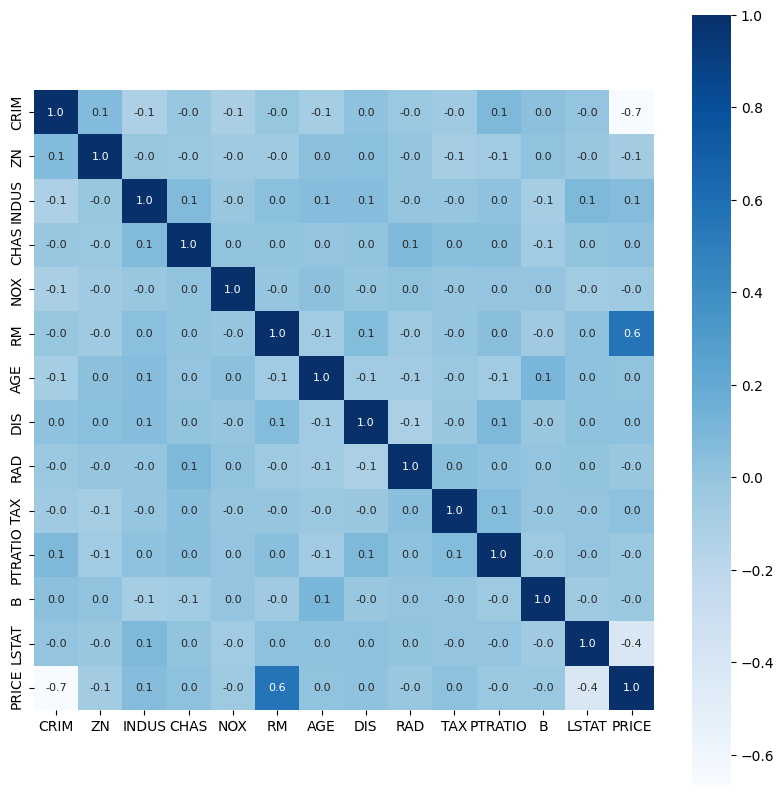

In [24]:
# constructinga heatmap to understand the correlation
plt.figure(figsize=(10,10))

sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

plt.show()

# Splitting the data and Traget

In [25]:
X = house_price_dataframe.drop(['PRICE'], axis=1)
Y = house_price_dataframe['PRICE']

In [26]:
print(X)
print(Y)

       CRIM     ZN  INDUS  CHAS    NOX    RM    AGE    DIS  RAD  TAX  PTRATIO  \
0    33.715  91.09  28.35     0  0.771  6.04  79.52   3.24   11  545    12.01   
1    85.565  82.25   1.66     1  0.835  6.80  85.52   1.74   12  486    23.74   
2    65.882  94.98  21.31     0  0.873  3.43  24.96  10.65   12  748    12.32   
3    53.883  72.57  27.79     0  0.772  4.53  96.10   5.28    7  291    14.72   
4    14.050  61.34   5.83     0  0.489  5.17  20.50   6.96   13  466    17.41   
..      ...    ...    ...   ...    ...   ...    ...    ...  ...  ...      ...   
501  48.253  84.92   1.04     0  0.593  5.67  47.16   3.36   21  645    23.08   
502  27.864  24.97   6.28     1  0.691  4.26   8.49   1.74    8  340    12.53   
503  73.243  48.94   0.72     0  0.870  3.30  39.39   7.54   19  515    12.65   
504  61.629  22.12  19.60     1  0.660  8.06  80.55   9.13   14  670    20.11   
505  14.644  98.77  26.99     1  0.746  8.89  90.28   1.36    7  266    12.82   

          B  LSTAT  
0    1

# Splitting the data into Training data and Test data

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 2)

In [30]:
print(X.shape ,X_train.shape, X_test.shape)

(506, 13) (404, 13) (102, 13)


# Model Training

# XGBoost Regressor

In [32]:
# Loading the model 
model = XGBRegressor()

In [33]:
# trainning the model with X_train
model.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

# Evalution

# Prediction on trainning data

In [34]:
# accuracy for prediction on trainning data
trainning_data_prediction = model.predict(X_train)

In [35]:
print(trainning_data_prediction)

[37.979927 57.149826 46.51907  37.711586 43.992737 58.2727   35.48127
 47.549816 42.65721  37.599514 50.129402 39.89908  39.72093  53.84678
 42.959854 35.210262 35.826843 48.940395 51.393204 56.812153 48.341476
 43.10946  46.161263 61.67024  31.728725 56.08184  55.128338 44.368126
 69.788086 49.190475 40.58919  29.602768 58.64436  43.888577 59.210533
 54.212055 42.788517 46.431667 47.66204  36.89746  37.722366 38.510864
 60.480824 46.289623 31.979568 39.80043  51.189743 47.399097 61.130405
 41.30878  38.53794  50.20185  64.128296 51.55855  46.180817 44.384342
 41.731197 59.187405 61.030247 34.84081  44.220997 38.030777 49.62415
 32.229076 50.21554  47.399357 37.71363  43.711346 51.431644 33.90694
 55.602417 46.860714 50.24857  45.680996 61.860172 48.87408  33.079876
 42.735382 43.491516 51.051056 54.679646 44.785316 44.270645 37.516365
 49.10829  46.250015 51.339207 46.95937  40.561134 48.402157 60.43788
 57.239494 58.683002 59.38741  39.61064  55.744488 56.69661  47.500824
 39.86972  

In [39]:
# R Squared error
score_1 = metrics.r2_score(Y_train, trainning_data_prediction)

# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_train, trainning_data_prediction)

print("R squared error :", score_1)
print("Mean_absolute_error :",score_2)

R squared error : 0.9999998797553804
Mean_absolute_error : 0.0018565655698871966


# Visualizing the actual Prices and predicted prices

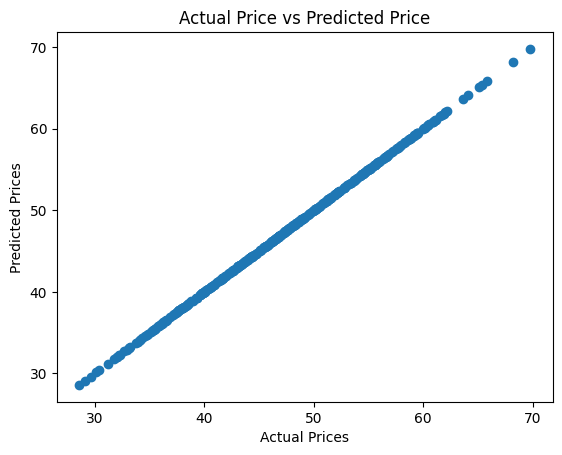

In [43]:
plt.scatter(Y_train, trainning_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.show()

# Prediction on Test Data

In [44]:
# accuarcy for prediction on test data
test_data_prediction = model.predict(X_test)

In [45]:
print(test_data_prediction)

[45.95122  62.0485   62.327797 47.750225 48.75181  42.163464 43.100765
 42.027252 48.859177 56.585667 53.15668  39.300564 47.27572  47.410522
 36.9209   41.497734 51.290417 54.873188 38.416687 41.064873 46.617138
 53.95616  51.290478 50.25424  42.34944  41.843822 49.115387 48.168827
 45.78667  43.776173 57.72779  52.654827 40.36256  44.19395  32.668056
 42.298405 44.85079  43.39777  43.134922 56.45939  41.147087 34.65064
 37.408318 58.429176 53.888874 43.117424 45.56207  46.112827 57.023678
 31.685312 34.735992 45.89814  40.816414 45.55709  47.99626  43.115025
 44.41657  36.898712 50.923542 42.628876 45.461548 42.144535 52.09044
 54.727013 37.552742 59.5582   33.129032 53.036106 35.970318 44.812332
 48.515457 54.94574  42.44881  50.260757 55.275196 50.80861  50.153294
 42.40799  48.19695  46.403435 48.945683 55.892925 34.747746 48.341343
 53.68187  51.15709  46.604046 51.541794 60.882736 48.25845  46.59387
 50.090084 44.92222  32.7284   52.11951  39.901524 34.447403 45.637524
 33.9849 

In [42]:
# R Squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R squared error :", score_1)
print("Mean_absolute_error :",score_2)

R squared error : 0.873902609417853
Mean_absolute_error : 2.0851997457766065
